In [ ]:
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")
library(data.table)
library(parallel)
library(pheatmap)
library(ape)
library(Biostrings)
library(canprot)
library(scales)

# data loading

In [27]:
metadata = read.delim(file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv"),header = T)
rownames(metadata) = metadata$assemblyID

In [ ]:
phyloKMat <- read.table(file.path(PHYLOGWAS_ROOT, "output/phyloK_728Poaceae_astral_20250407.txt"))
colnames(phyloKMat) <- rownames(phyloKMat)

In [31]:
envData = read.table(file.path(PHYLOGWAS_ROOT, "output/envData_707Poaceae_20250804.txt"))

In [32]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"
envDf$assemblyID = as.factor(envDf$assemblyID)

In [33]:
# load tree
spTre = read.tree(file.path(PHYLOGWAS_ROOT, "output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk"))
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [34]:
commonID = Reduce("intersect",list(spTre.rooted$tip.label,rownames(envDf),metadata$assemblyID))
length(commonID)

[1] 687

In [35]:
spTre.rooted = keep.tip(spTre.rooted,commonID)
spTre.rooted.resolved = ape::multi2di(spTre.rooted) # for permulation

# amino acid composition calculation

In [33]:
aaFasta = mclapply(list.files(file.path(PHYLOGWAS_ROOT, "output/aminoAcidPerTaxa/"),pattern = "*.fa",full.names = T),function(x) readAAStringSet(x),mc.cores = 30)

aa.comp = mclapply(aaFasta,function(x){
    tmp = letterFrequency(x,letters = AA_STANDARD)
    return(colSums(tmp)/sum(tmp))
},mc.cores = 5)


aa.comp = Reduce("rbind",aa.comp)

rownames(aa.comp) = gsub(".fa","",list.files(file.path(PHYLOGWAS_ROOT, "output/aminoAcidPerTaxa/"),pattern = "*.fa"))

aa.comp = aa.comp[commonID,]

dim(aa.comp)

[1] 687  20

In [34]:
data.table::fwrite(aa.comp,file.path(PHYLOGWAS_ROOT, "output/poaceae_aaComposition_20251008.txt"),sep = "\t",row.names = T,col.names = T)

x being coerced from class: matrix to data.table



In [34]:
aa.comp = read.table(file.path(PHYLOGWAS_ROOT, "output/poaceae_aaComposition_20251008.txt"),row.names =1,header = T)

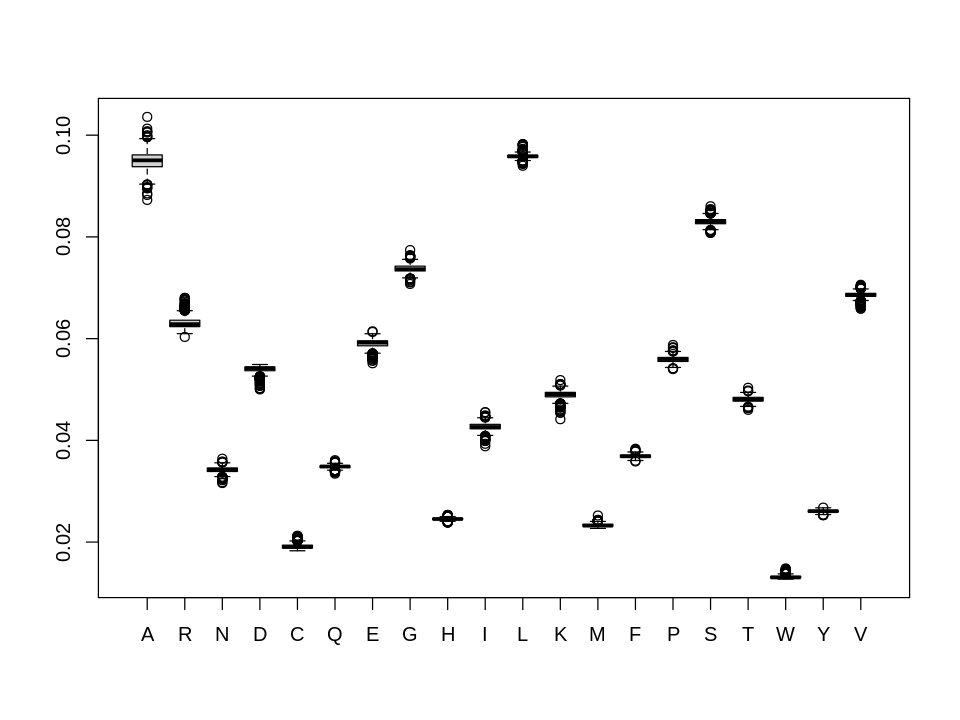

In [35]:
options(repr.plot.width=8, repr.plot.height=6)
boxplot(aa.comp)

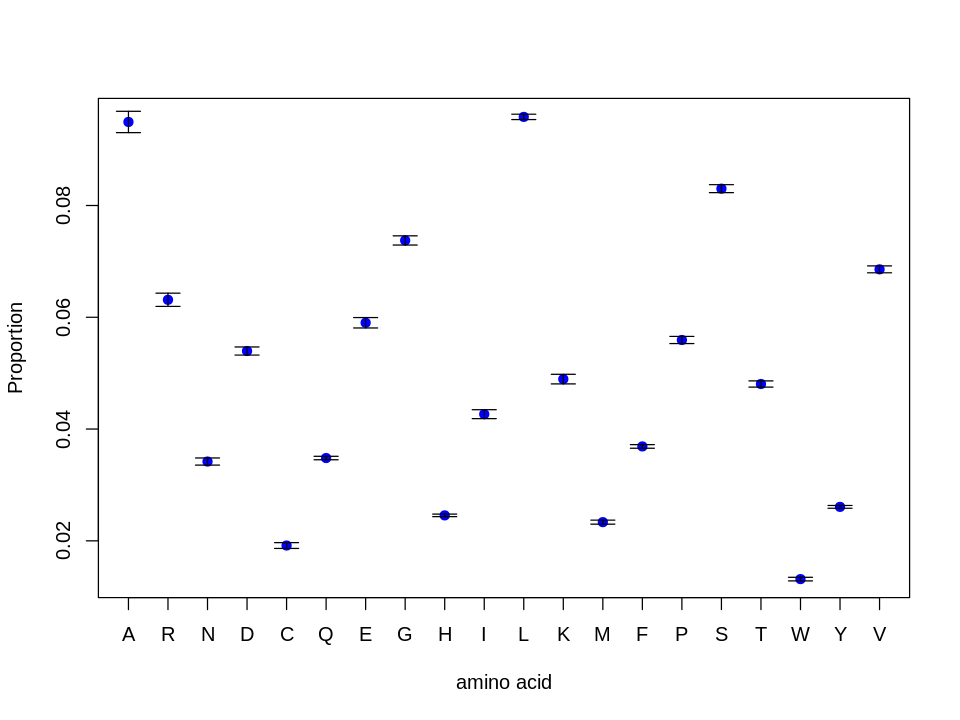

In [36]:
plot(apply(aa.comp,2,mean),xlab= "amino acid",ylab = "Proportion",xaxt = "n",pch = 19,col = "blue")
arrows(x0 = 1:20,x1 = 1:20, 
       y0 = apply(aa.comp,2,mean)-apply(aa.comp,2,sd), y1 = apply(aa.comp,2,mean)+apply(aa.comp,2,sd),
       angle = 90, code = 3,length = .1)
axis(1, at = 1:20,labels = colnames(aa.comp))

In [37]:
sort(apply(aa.comp,2,sd)/apply(aa.comp,2,mean))

L           S           F           Q           V           H 
0.005026564 0.008588036 0.008636168 0.008943973 0.009008291 0.009244475 
          Y           G           P           T           D           M 
0.009642555 0.011150318 0.011481388 0.011492262 0.013436934 0.015343007 
          E           K           N           R           I           A 
0.015769533 0.017590458 0.018617240 0.018723067 0.018739854 0.020092306 
          W           C 
0.024359976 0.027060170

In [38]:
range(apply(aa.comp,2,sd)/apply(aa.comp,2,mean))

[1] 0.005026564 0.027060170

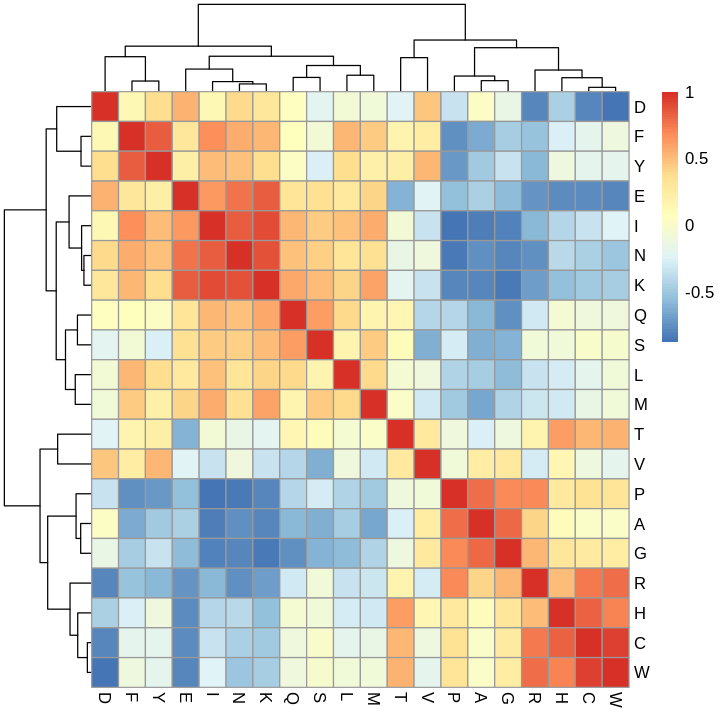

In [39]:
options(repr.plot.width=6, repr.plot.height=6)
pheatmap::pheatmap(cor(aa.comp))

# a.a. composition per OG

In [40]:
aaFastaPerOG = mclapply(list.files(file.path(PHYLOGWAS_ROOT, "output/orthofinderProteinMSAs_fullset_20250710/"),pattern = "*.fa",
                                   full.names = T),function(x) readAAStringSet(x),mc.cores = 5)

names(aaFastaPerOG) = gsub(".fa","",list.files(file.path(PHYLOGWAS_ROOT, "output/orthofinderProteinMSAs_fullset_20250710/"),pattern = "*.fa"))

aa.comp.og = mclapply(aaFastaPerOG,function(x){
    tmp = letterFrequency(x,letters = AA_STANDARD)
    rownames(tmp) = names(x)
    return(tmp)
},mc.cores = 5)


In [ ]:
aa.comp.perOG = mclapply(aa.comp.og,function(x) {
    tmp = apply(x,2,function(a) tapply(a,limma::strsplit2(rownames(x),":")[,2],sum))
    return(as.data.frame(tmp)[commonID,])
    },mc.cores = 5)

aa.comp.perOG.array = simplify2array(lapply(aa.comp.perOG,as.matrix))

### filter/subset based on protein abundance

In [ ]:
FPKM = read.csv(file.path(PHYLOGWAS_ROOT, "data/maxFPKM_v5.csv"))

In [ ]:
mappingFile = read.table(file.path(PHYLOGWAS_ROOT, "data/OGToZm_mapping_v2.txt"))
colnames(mappingFile) = c("ZmID","OG")
mappingFile$ZmGeneID = substr(mappingFile$ZmID,1,15)

In [ ]:
FPKMmerged = merge(FPKM,mappingFile,by.x = "Gene",by.y = "ZmGeneID",all.x = T)

In [ ]:
table(is.na(FPKMmerged$OG))

In [ ]:
with(FPKMmerged,boxplot(log2(maxFPKM+1)~is.na(OG)))

In [49]:
# --- Colors (clustered by tissue; strong contrast across tissues) ---
series_cols <- c(
  # Reproductive (4) - magenta family
  "#CC79A7", "#A64D8A", "#E78AC3", "#8F3D8F",
  # Kernel (6) - sky/steel blue family
  "#56B4E9", "#2A7FB8", "#66CCFF", "#99DDFF", "#1F78B4", "#4C9ED9",
  # Shoot (2) - grayscale for max contrast
  "#000000", "#666666",
  # Leaf (5) - green/teal family
  "#009E73", "#007A59", "#33CC99", "#1B9E77", "#66E0B2",
  # Reproductive (1) - distinct magenta variant
  "#E7298A",
  # Root (5) - vermillion/orange family (no yellow)
  "#D55E00", "#A84400", "#FF751A", "#B94E00", "#803300"
)

# --- Line types (varied within each tissue cluster) ---
series_ltys <- c(
  # Reproductive (4)
  "solid", "dashed", "dotted", "dotdash",
  # Kernel (6)
  "solid", "dashed", "dotted", "dotdash", "longdash", "twodash",
  # Shoot (2)
  "solid", "dashed",
  # Leaf (5)
  "solid", "dashed", "dotted", "dotdash", "longdash",
  # Reproductive (1)
  "solid",
  # Root (5)
  "solid", "dashed", "dotted", "dotdash", "longdash"
)


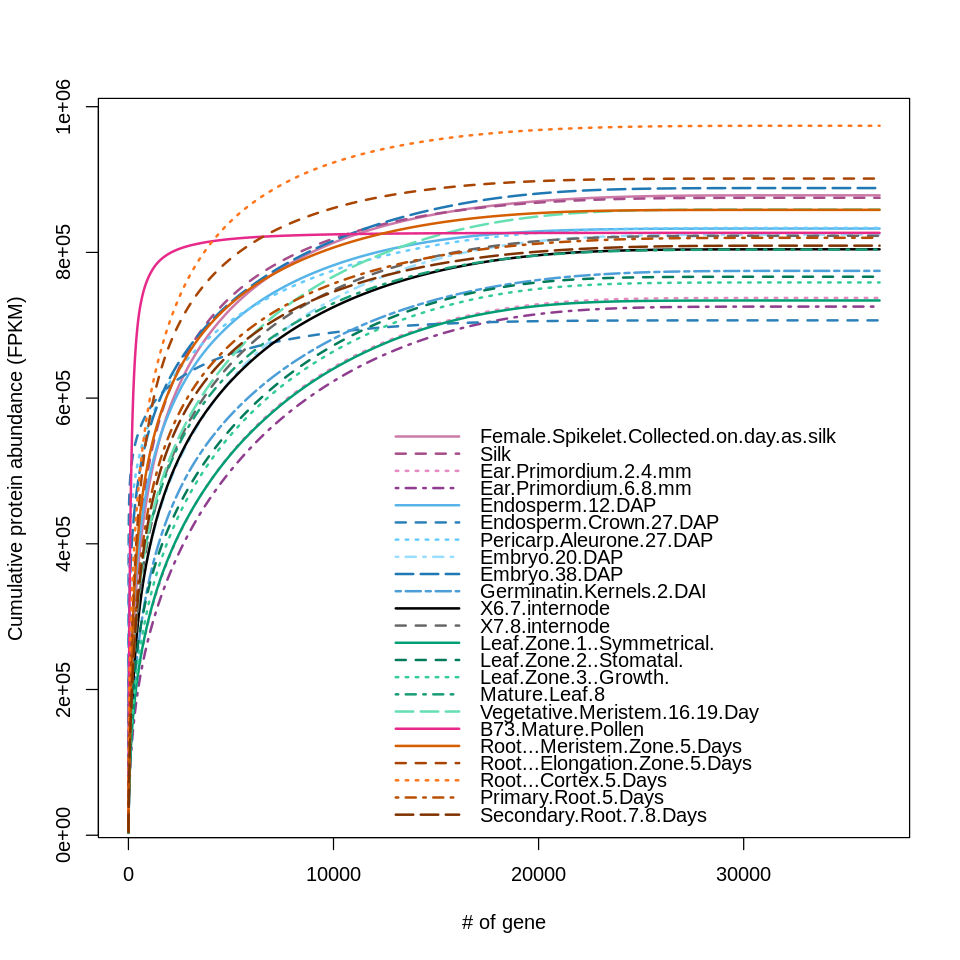

In [50]:
options(repr.plot.width=8, repr.plot.height=8)
plot(cumsum(sort(FPKMmerged$Root...Cortex.5.Days,decreasing = T)),type ='n',
     xlab = "# of gene", ylab = "Cumulative protein abundance (FPKM)")
for (i in 23:45){
    lines(cumsum(sort(FPKMmerged[,i],decreasing = T)),
          col = series_cols[i-22],lty =series_ltys[i-22],lwd = 2)
}
# lines(cumsum(sort(FPKMmerged$maxFPKM,decreasing = T)),col = "red",lwd = 5,lty = 1)
legend("bottomright",legend = colnames(FPKMmerged)[23:45],
       col = series_cols,lty =series_ltys,seg.len = 3,
       bty = 'n',y.intersp = .6,lwd =2)

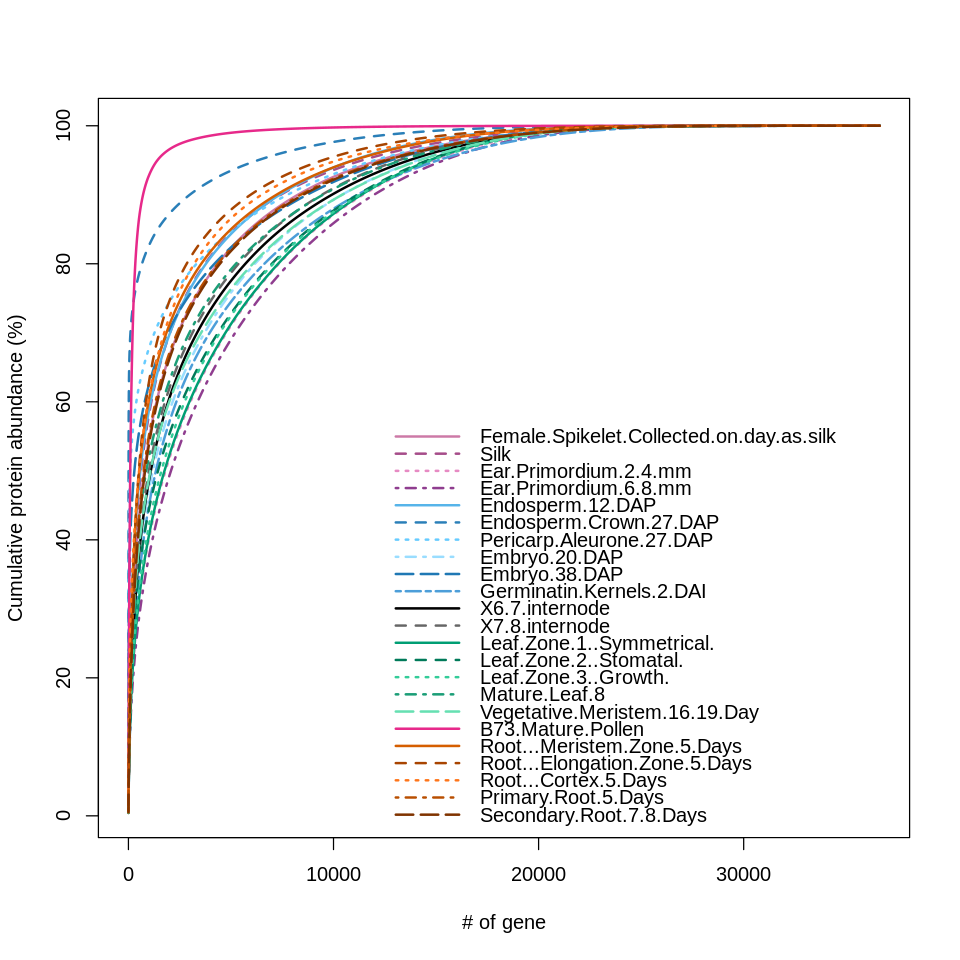

In [51]:
options(repr.plot.width=8, repr.plot.height=8)
cutoffs = c()
topHundredPort = c()
plot(cumsum(sort(FPKMmerged$`Mature.Leaf.8`,decreasing = T))/sum(FPKMmerged$`Mature.Leaf.8`)*100,type ='n',
     xlab = "# of gene", ylab = "Cumulative protein abundance (%)")
for (i in 23:45){
    cumPort = cumsum(sort(FPKMmerged[,i],decreasing = T))/sum(FPKMmerged[,i])*100
    cutoffs = c(cutoffs,which(cumPort>50)[1])
    topHundredPort = c(topHundredPort,cumPort[100])
    lines(cumPort,col = series_cols[i-22],lty = series_ltys[i-22],lwd = 2)
}
# lines(cumsum(sort(FPKMmerged$maxFPKM,decreasing = T))/sum(FPKMmerged$maxFPKM)*100,col = "red",lwd = 5,lty = 1)
legend("bottomright",legend = colnames(FPKMmerged)[23:45],col = series_cols,lty = series_ltys,
       bty = 'n',y.intersp = .6,lwd =2,seg.len = 3)

In [53]:
highProt = list()
topProt = list()
for(i in 1:23){
    highProt[[i]] = which(rank(FPKMmerged[,i+22]) > (nrow(FPKMmerged) - cutoffs[i]))
    topProt[[i]] = which(rank(FPKMmerged[,i+22]) > (nrow(FPKMmerged) - 100))
}


In [54]:
names(highProt) = names(cutoffs)
names(topProt) = names(cutoffs)

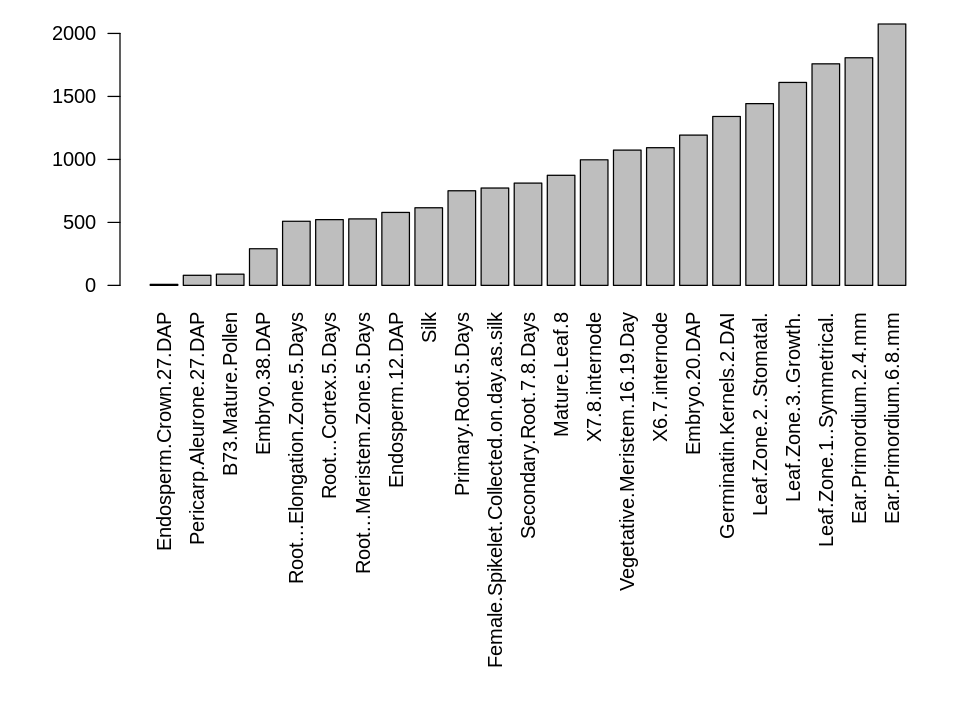

In [55]:
options(repr.plot.width=8, repr.plot.height=6)
par(mar = c(18,5,1,1))
barplot(sort(sapply(highProt,length)),las = 2)

In [56]:
names(topHundredPort) = names(cutoffs)

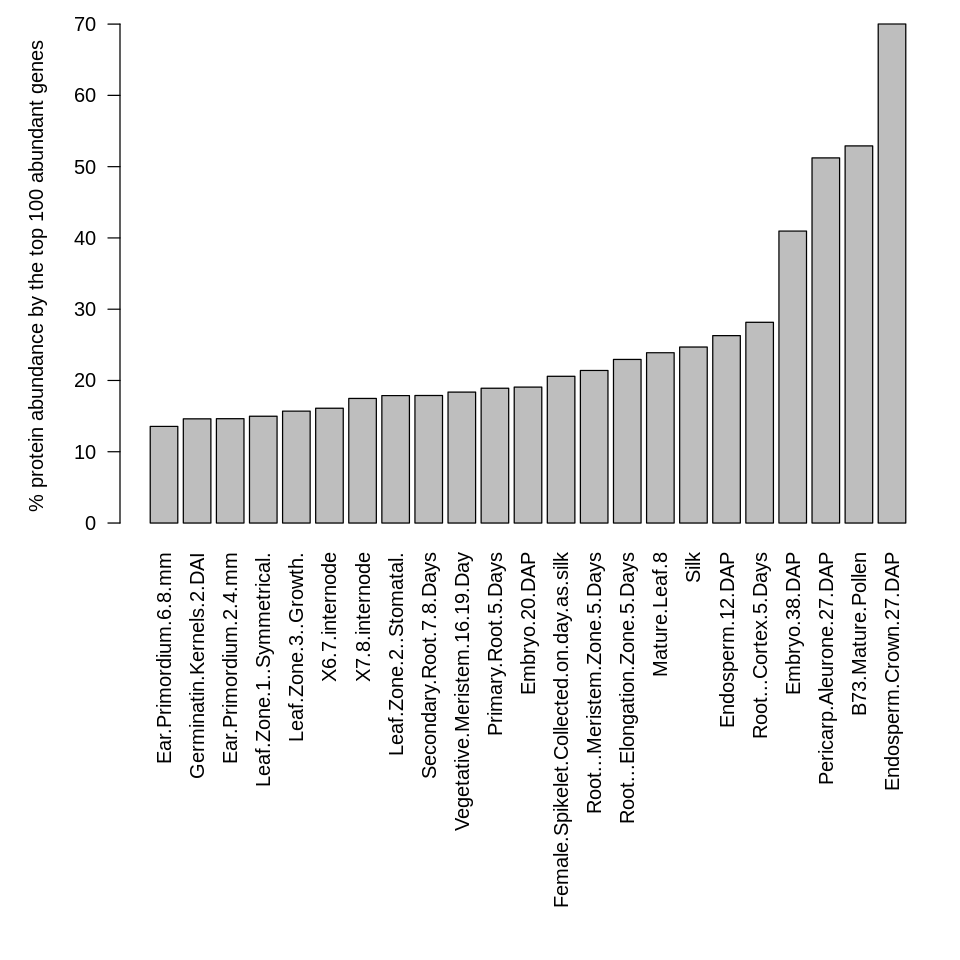

In [57]:
options(repr.plot.width=8, repr.plot.height=8)
par(mar = c(18,5,1,1))
barplot(sort(topHundredPort),las = 2,ylab = "% protein abundance by the top 100 abundant genes")

In [58]:
length(unique(unlist(highProt)))

[1] 4279

In [59]:
abundantOG = na.omit(FPKMmerged[unique(unlist(highProt)),]$OG)
length(abundantOG)
abundantOGLeaf = na.omit(FPKMmerged[unique(unlist(highProt[grep("Leaf",names(highProt))])),]$OG)
length(abundantOGLeaf)
abundantOGRoot = na.omit(FPKMmerged[unique(unlist(highProt[grep("Root",names(highProt))])),]$OG)
length(abundantOGRoot)

[1] 2676

[1] 1744

[1] 590

In [60]:
length(intersect(abundantOGLeaf,abundantOGRoot))
length(setdiff(abundantOGLeaf,abundantOGRoot))
length(setdiff(abundantOGRoot,abundantOGLeaf))

[1] 384

[1] 1330

[1] 196

In [61]:
topOG = na.omit(FPKMmerged[unique(unlist(topProt)),]$OG)
length(topOG)
topOGLeaf = na.omit(FPKMmerged[unique(unlist(topProt[grep("Leaf",names(highProt))])),]$OG)
length(topOGLeaf)
topOGRoot = na.omit(FPKMmerged[unique(unlist(topProt[grep("Root",names(highProt))])),]$OG)
length(topOGRoot)

[1] 370

[1] 115

[1] 108

In [62]:
length(intersect(topOGLeaf,topOGRoot))
length(setdiff(topOGLeaf,topOGRoot))
length(setdiff(topOGRoot,topOGLeaf))

[1] 36

[1] 79

[1] 72

In [63]:
nrow(FPKMmerged)

[1] 36625

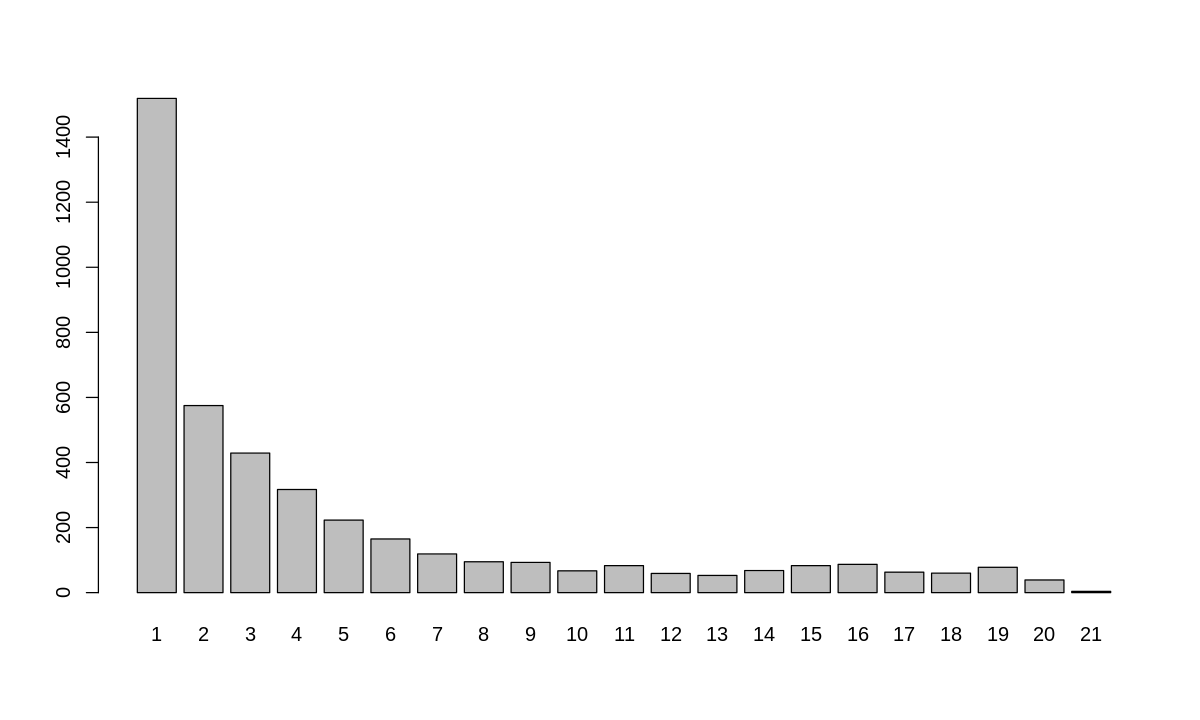

In [64]:
options(repr.plot.width=10, repr.plot.height=6)
barplot(table(table(unlist(highProt))))

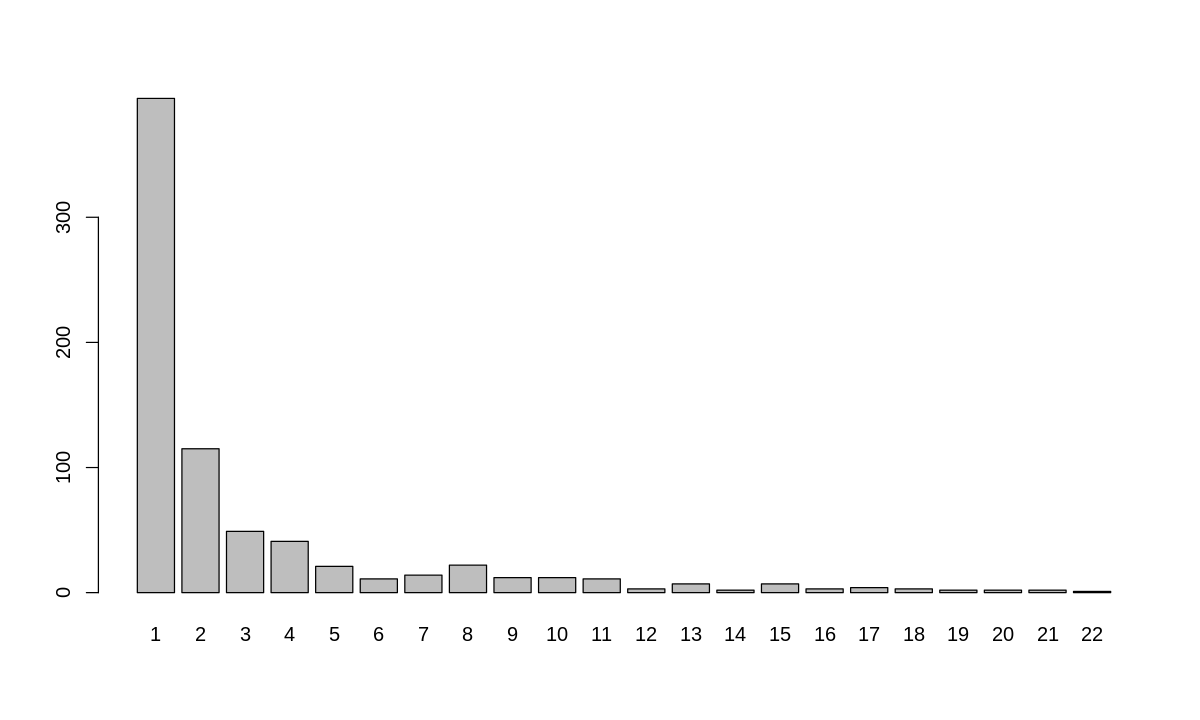

In [65]:
options(repr.plot.width=10, repr.plot.height=6)
barplot(table(table(unlist(topProt))))

In [66]:
aa.comp.others = apply(aa.comp.perOG.array[,,!dimnames(aa.comp.perOG.array)[[3]]%in%abundantOG],c(1,2),function(x) sum(x,na.rm = T))
aa.comp.others = aa.comp.others/rowSums(aa.comp.others)

In [67]:
aa.comp.abundant = apply(aa.comp.perOG.array[,,abundantOG],c(1,2),function(x) sum(x,na.rm = T))
aa.comp.abundant = aa.comp.abundant/rowSums(aa.comp.abundant)

In [68]:
aa.comp.abundantLeaf = apply(aa.comp.perOG.array[,,abundantOGLeaf],c(1,2),function(x) sum(x,na.rm = T))
aa.comp.abundantLeaf = aa.comp.abundantLeaf/rowSums(aa.comp.abundantLeaf)

In [69]:
aa.comp.abundantRoot = apply(aa.comp.perOG.array[,,abundantOGRoot],c(1,2),function(x) sum(x,na.rm = T))
aa.comp.abundantRoot = aa.comp.abundantRoot/rowSums(aa.comp.abundantRoot)

In [70]:
aa.comp.topLeaf = apply(aa.comp.perOG.array[,,topOGLeaf],c(1,2),function(x) sum(x,na.rm = T))
aa.comp.topLeaf = aa.comp.topLeaf/rowSums(aa.comp.topLeaf)

In [71]:
aa.comp.topRoot = apply(aa.comp.perOG.array[,,topOGRoot],c(1,2),function(x) sum(x,na.rm = T))
aa.comp.topRoot = aa.comp.topRoot/rowSums(aa.comp.topRoot)

In [72]:
aa.prop.perOG = array(apply(aa.comp.perOG.array,3,function(x) x/rowSums(x,na.rm = T)),dim = dim(aa.comp.perOG.array))

In [73]:
dim(aa.prop.perOG)

[1]   687    20 22196

In [74]:
dimnames(aa.prop.perOG) = dimnames(aa.comp.perOG.array)

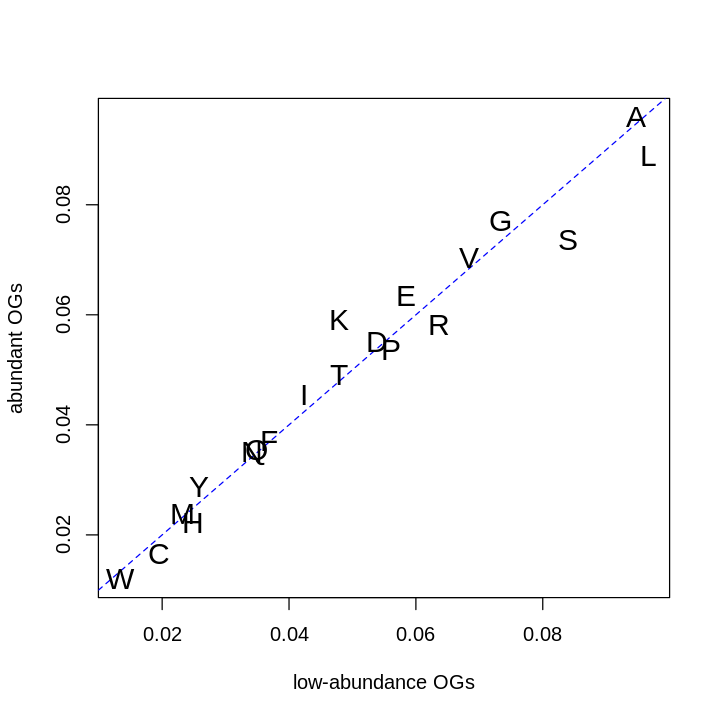

In [75]:
options(repr.plot.width=6, repr.plot.height=6)
plot(apply(aa.comp.others,2,mean),apply(aa.comp.abundant,2,mean),xlab = "low-abundance OGs",ylab = "abundant OGs",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.others,2,mean),apply(aa.comp.abundant,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

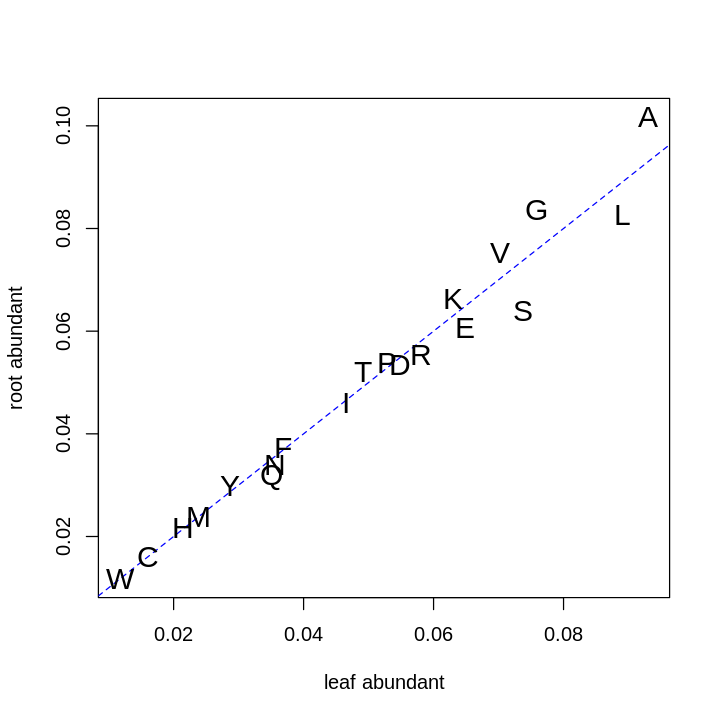

In [76]:
options(repr.plot.width=6, repr.plot.height=6)
plot(apply(aa.comp.abundantLeaf,2,mean),apply(aa.comp.abundantRoot,2,mean),xlab = "leaf abundant",ylab = "root abundant",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.abundantLeaf,2,mean),apply(aa.comp.abundantRoot,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

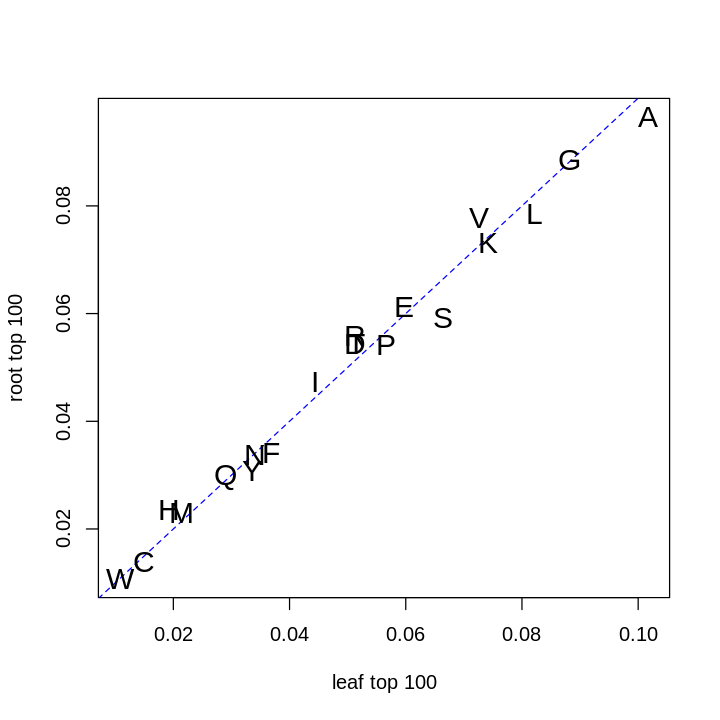

In [77]:
options(repr.plot.width=6, repr.plot.height=6)
plot(apply(aa.comp.topLeaf,2,mean),apply(aa.comp.topRoot,2,mean),xlab = "leaf top 100",ylab = "root top 100",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.topLeaf,2,mean),apply(aa.comp.topRoot,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

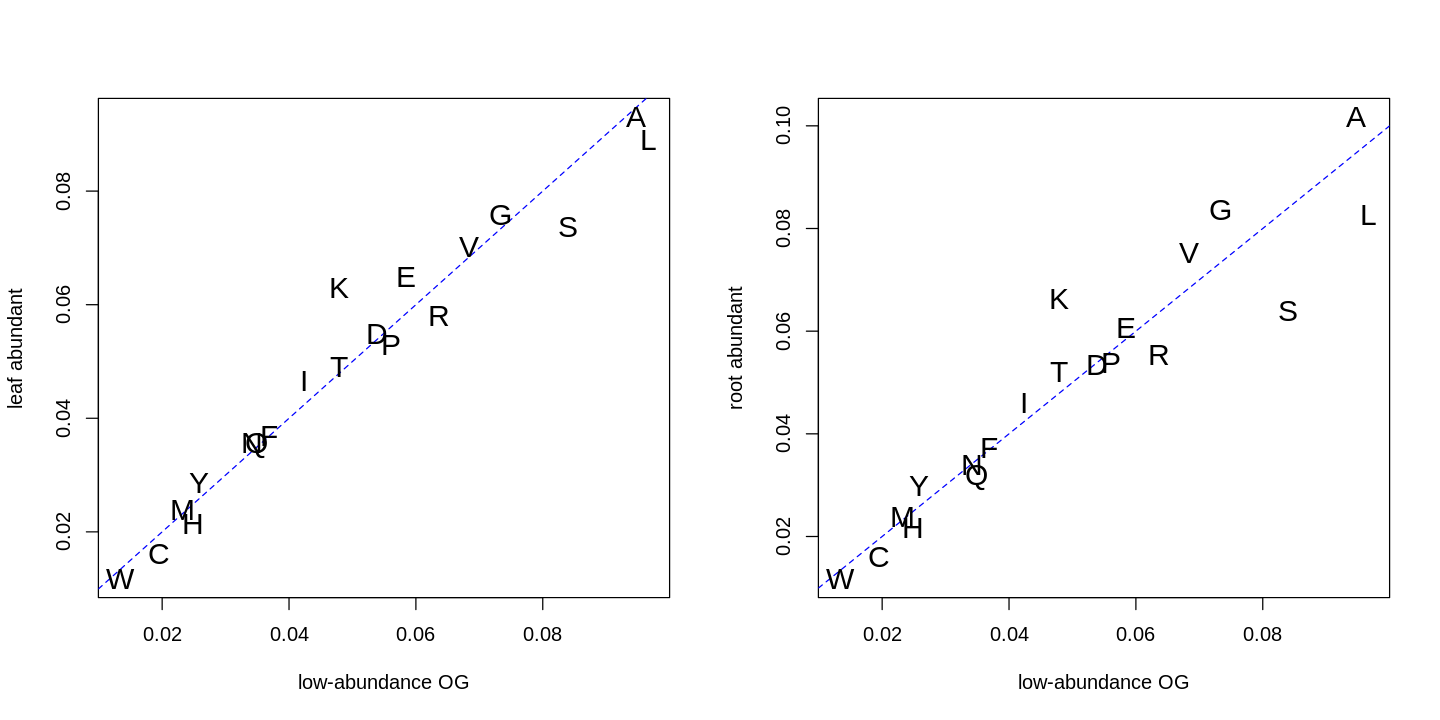

In [78]:
options(repr.plot.width=12, repr.plot.height=6)
par(mfrow = c(1,2))
plot(apply(aa.comp.others,2,mean),apply(aa.comp.abundantLeaf,2,mean),xlab = "low-abundance OG",ylab = "leaf abundant",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.others,2,mean),apply(aa.comp.abundantLeaf,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

plot(apply(aa.comp.others,2,mean),apply(aa.comp.abundantRoot,2,mean),xlab = "low-abundance OG",ylab = "root abundant",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.others,2,mean),apply(aa.comp.abundantRoot,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

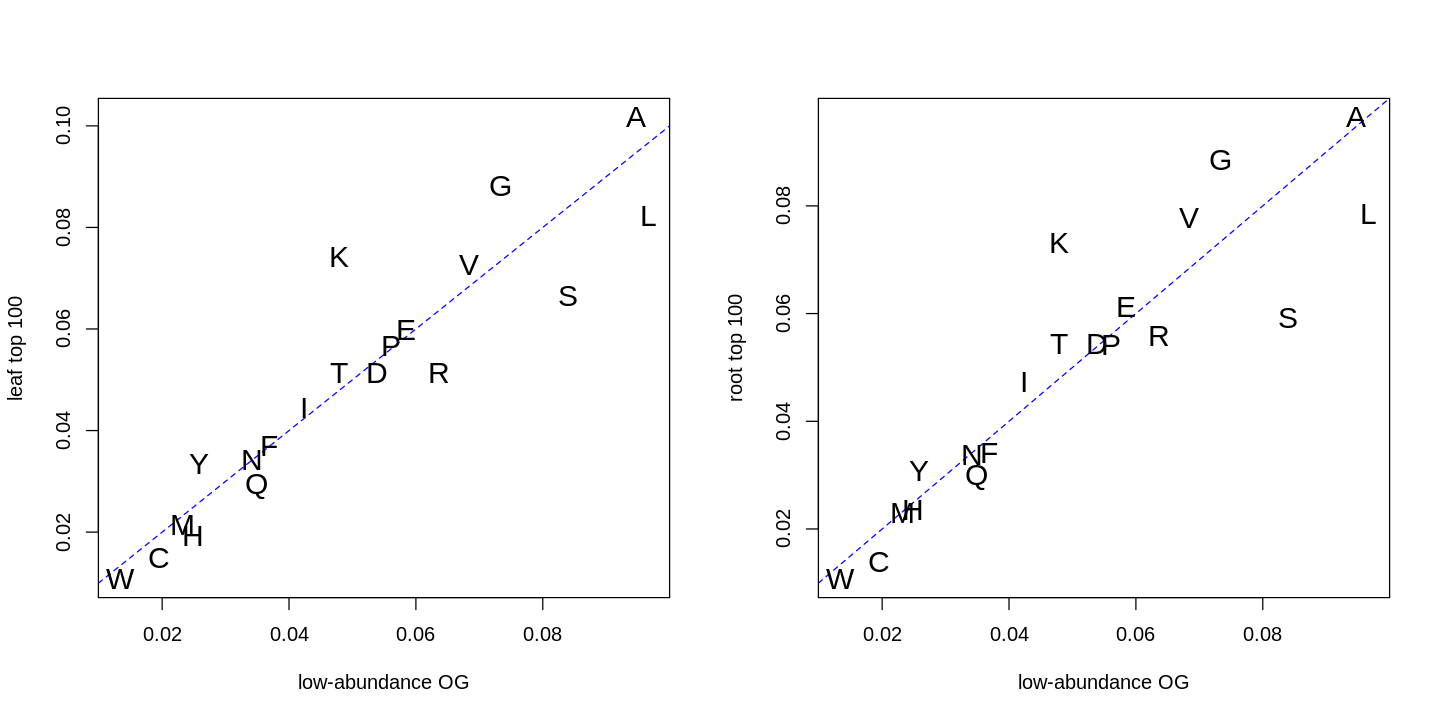

In [79]:
options(repr.plot.width=12, repr.plot.height=6)
par(mfrow = c(1,2))
plot(apply(aa.comp.others,2,mean),apply(aa.comp.topLeaf,2,mean),xlab = "low-abundance OG",ylab = "leaf top 100",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.others,2,mean),apply(aa.comp.topLeaf,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

plot(apply(aa.comp.others,2,mean),apply(aa.comp.topRoot,2,mean),xlab = "low-abundance OG",ylab = "root top 100",type ='n')
abline(a = 0, b = 1,col = "blue",lty = 2)
text(apply(aa.comp.others,2,mean),apply(aa.comp.topRoot,2,mean),labels = colnames(aa.comp.abundant),cex = 1.5)

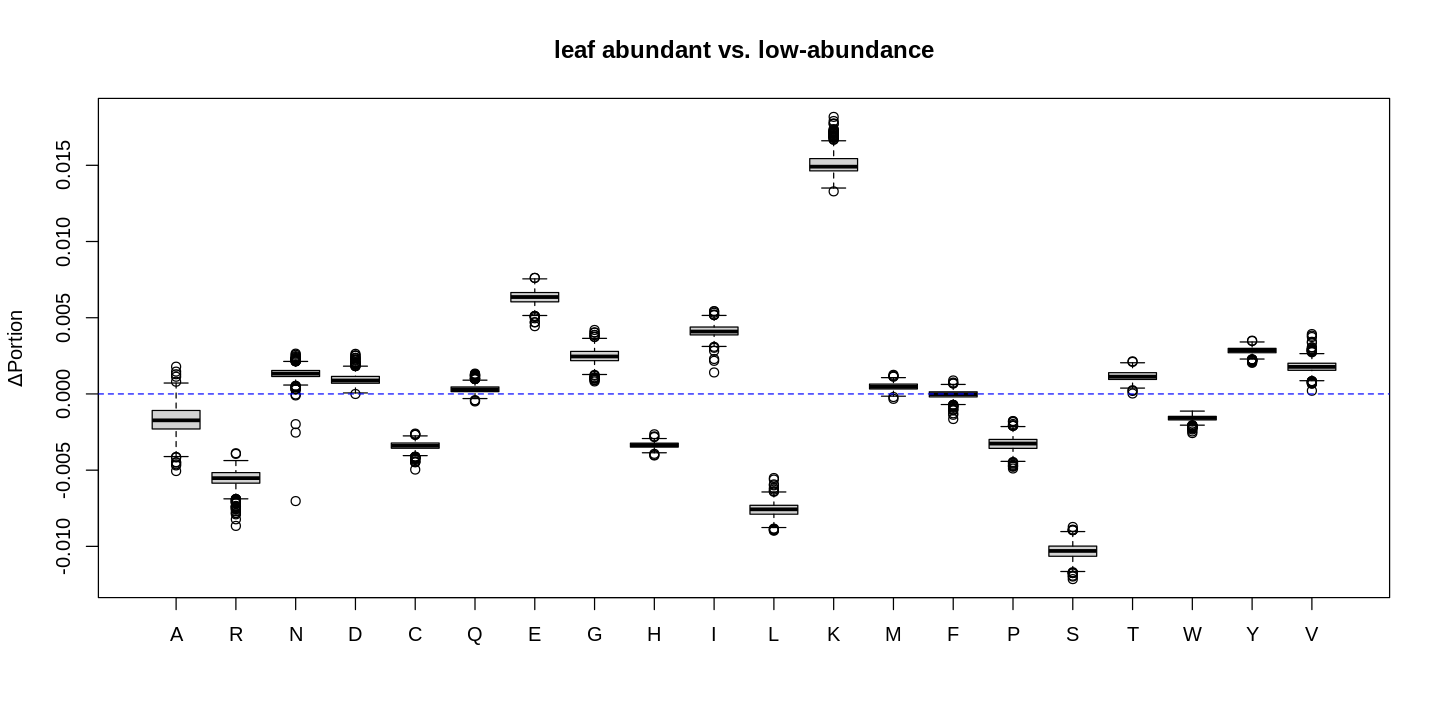

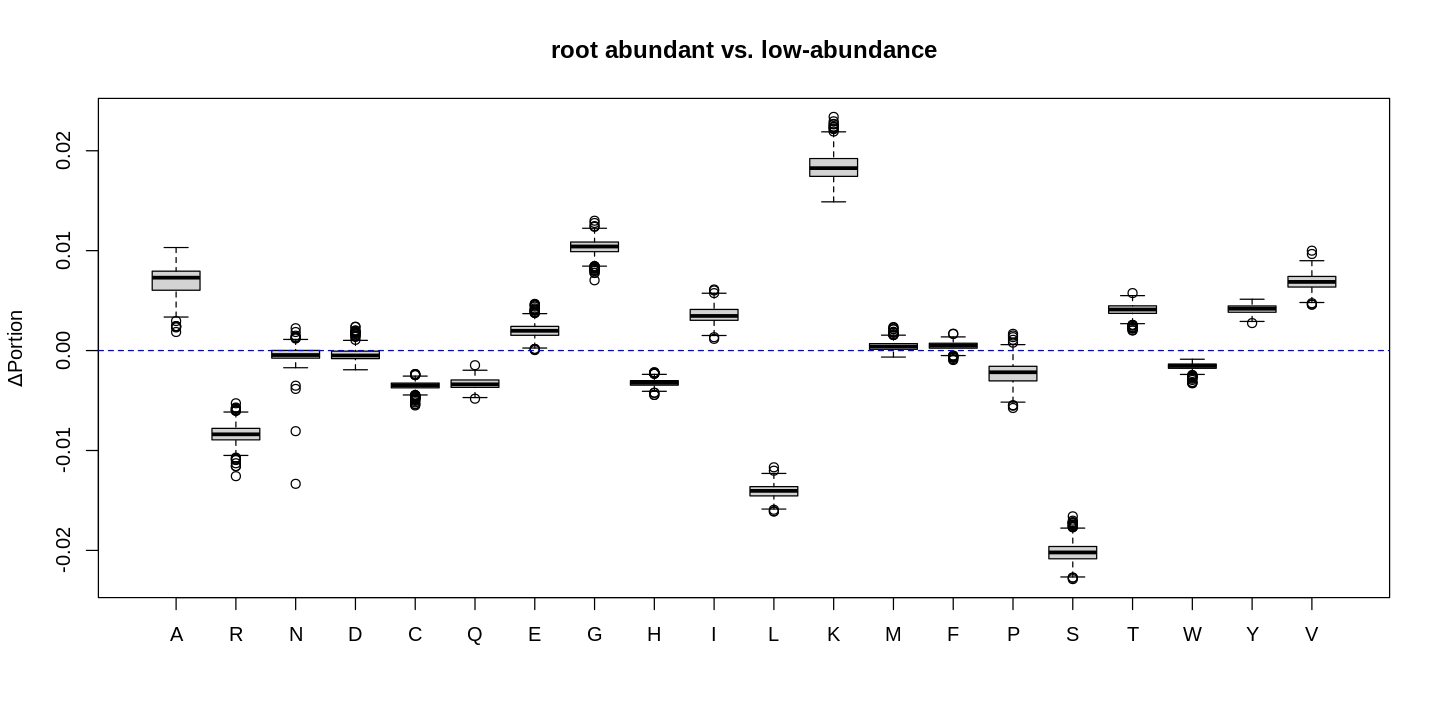

In [80]:
options(repr.plot.width=12, repr.plot.height=6)
boxplot((aa.comp.abundantLeaf-aa.comp.others),
        ylab = expression(paste(Delta,"Portion")),main = "leaf abundant vs. low-abundance")
abline(h=0,col = 'blue',lty = 2)
boxplot((aa.comp.abundantRoot-aa.comp.others),
        ylab = expression(paste(Delta,"Portion")),main = "root abundant vs. low-abundance")
abline(h=0,col = 'blue',lty = 2)

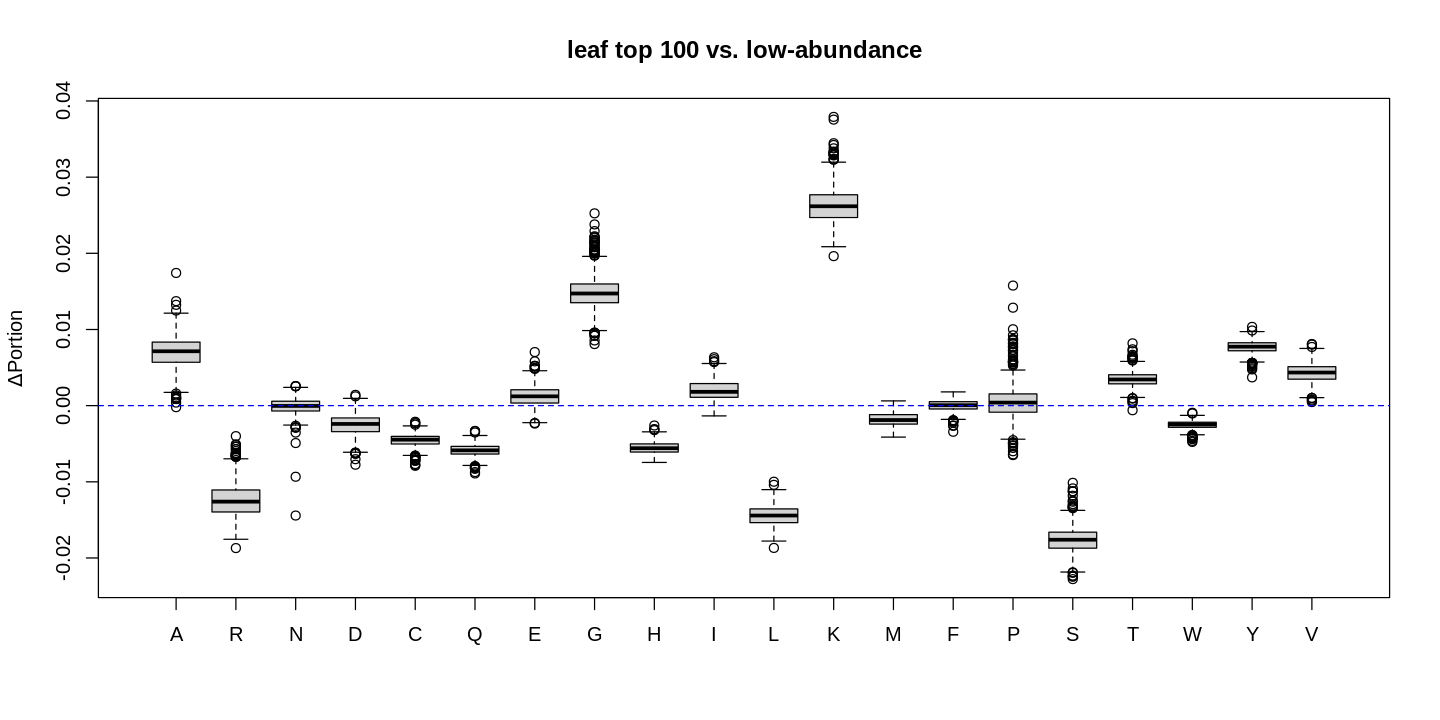

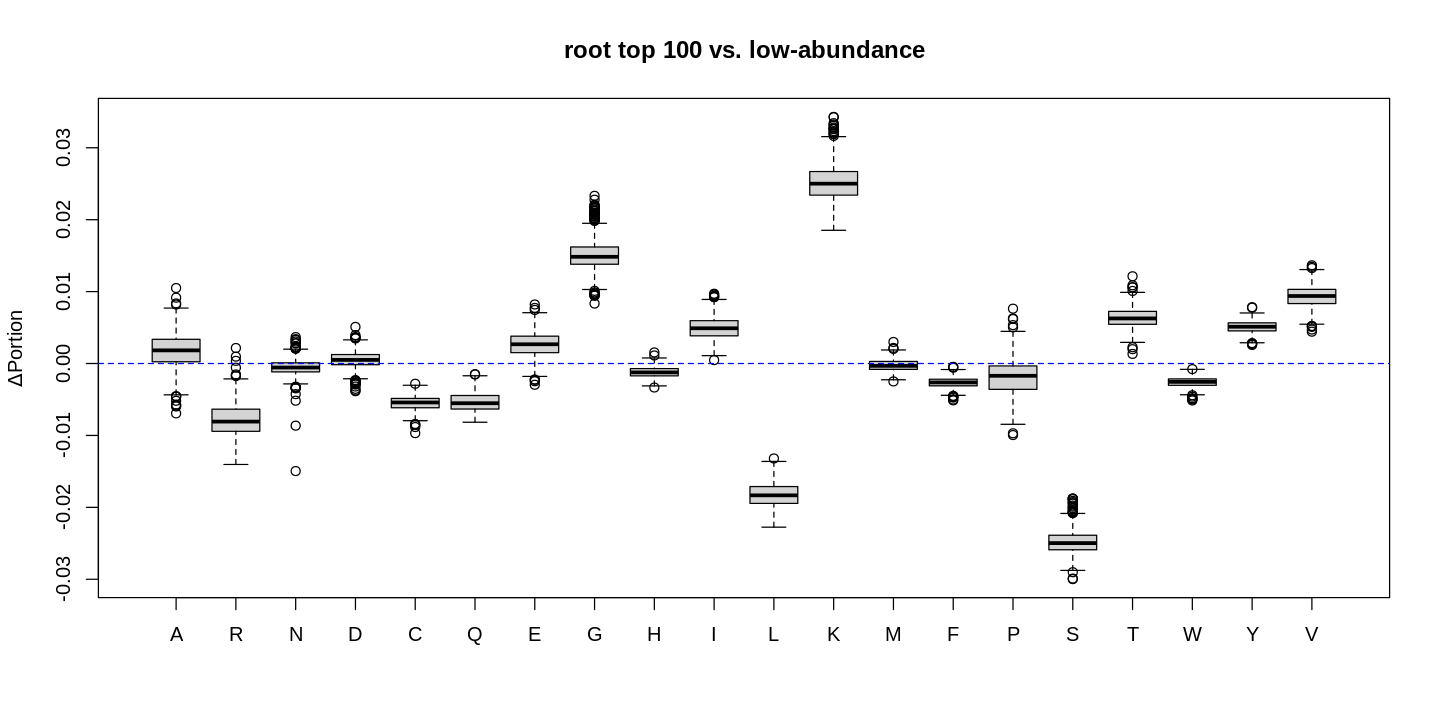

In [81]:
options(repr.plot.width=12, repr.plot.height=6)
boxplot((aa.comp.topLeaf-aa.comp.others),
        ylab = expression(paste(Delta,"Portion")),main = "leaf top 100 vs. low-abundance")
abline(h=0,col = 'blue',lty = 2)
boxplot((aa.comp.topRoot-aa.comp.others),
        ylab = expression(paste(Delta,"Portion")),main = "root top 100 vs. low-abundance")
abline(h=0,col = 'blue',lty = 2)

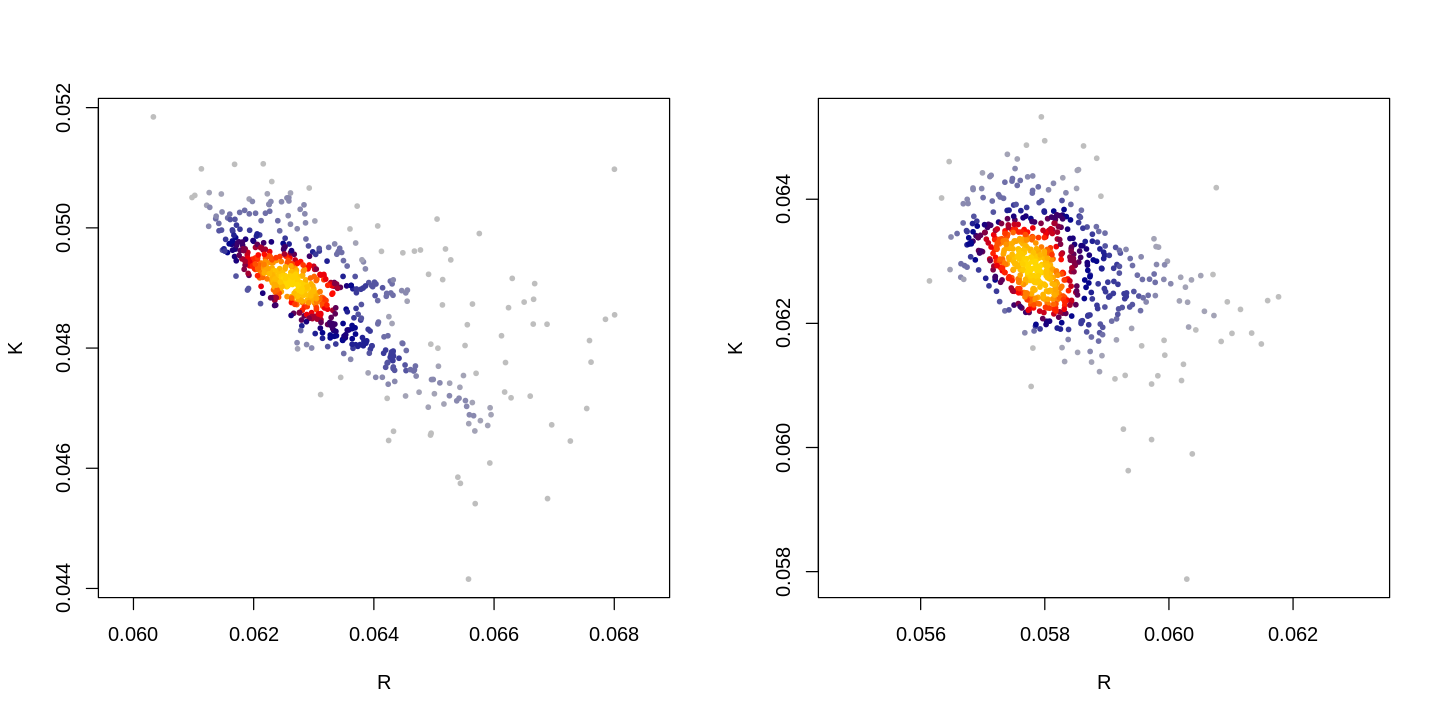

In [82]:
options(repr.plot.width=12, repr.plot.height=6)
par(mfrow = c(1,2))
LSD::heatscatter((aa.comp)[,"R"],(aa.comp)[,"K"],xlab = "R",ylab="K",main = "",asp = 1)
LSD::heatscatter((aa.comp.abundantLeaf)[,"R"],(aa.comp.abundantLeaf)[,"K"],xlab = "R",ylab="K",main = "",asp = 1)

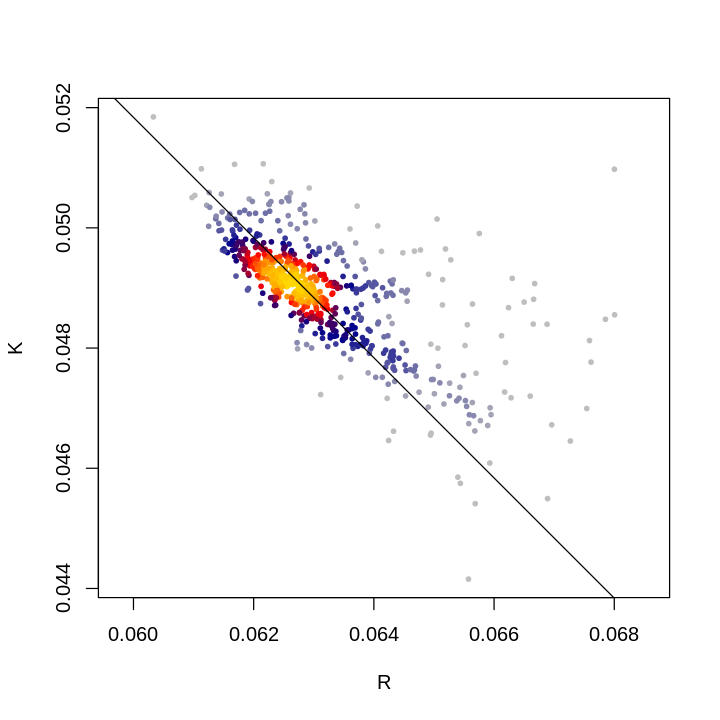

In [83]:
options(repr.plot.width=6, repr.plot.height=6)
LSD::heatscatter((aa.comp)[,"R"],(aa.comp)[,"K"],xlab = "R",ylab="K",main = "",asp =1)
abline(a = median(aa.comp[,"R"]+aa.comp[,"K"]), b= -1)

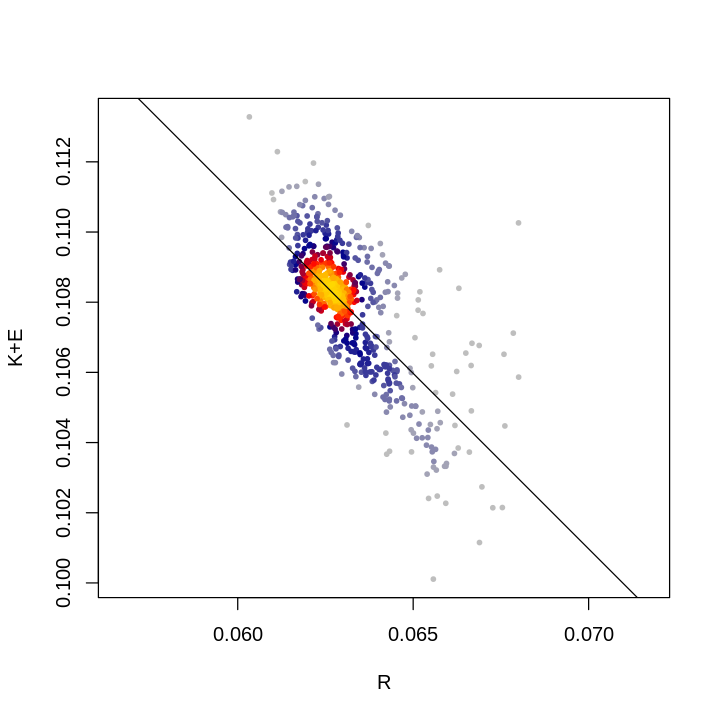

In [84]:
LSD::heatscatter((aa.comp)[,"R"],(aa.comp)[,"K"]+(aa.comp)[,"E"],
                 xlab = "R",ylab="K+E",main = "",
                 asp =1)
abline(a = median(aa.comp[,"R"]+aa.comp[,"K"]+aa.comp[,"E"]), b= -1)

In [85]:
cor((aa.comp.abundantLeaf)[,"R"],(aa.comp.abundantLeaf)[,"K"],method = "spearman")
cor((aa.comp)[,"R"],(aa.comp)[,"K"],method = "spearman")

[1] -0.4128012

[1] -0.7158265

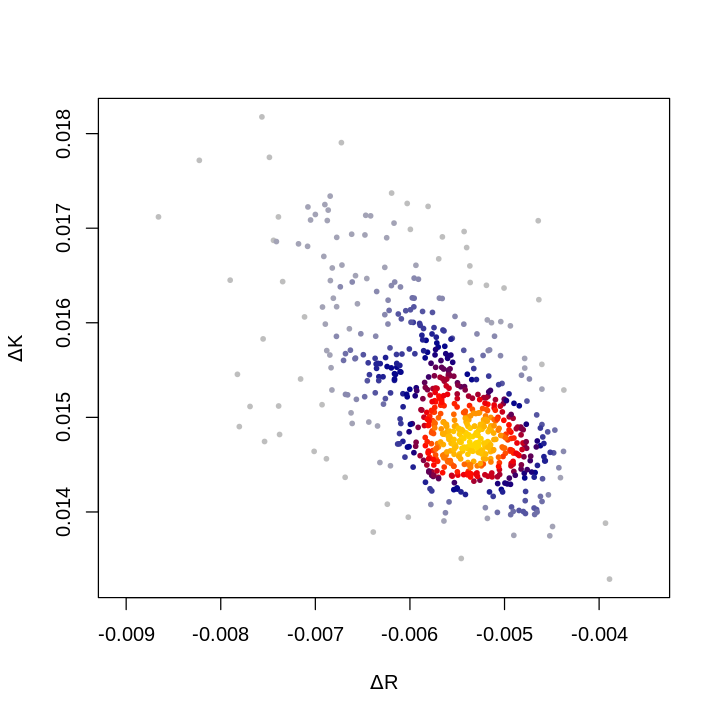

In [86]:
options(repr.plot.width=6, repr.plot.height=6)
LSD::heatscatter((aa.comp.abundantLeaf-aa.comp.others)[,"R"],
                 (aa.comp.abundantLeaf-aa.comp.others)[,"K"],
                 xlab = expression(paste(Delta,"R")),ylab = expression(paste(Delta,"K")),main = "",asp = 1)
abline(a = 0, b= -1)

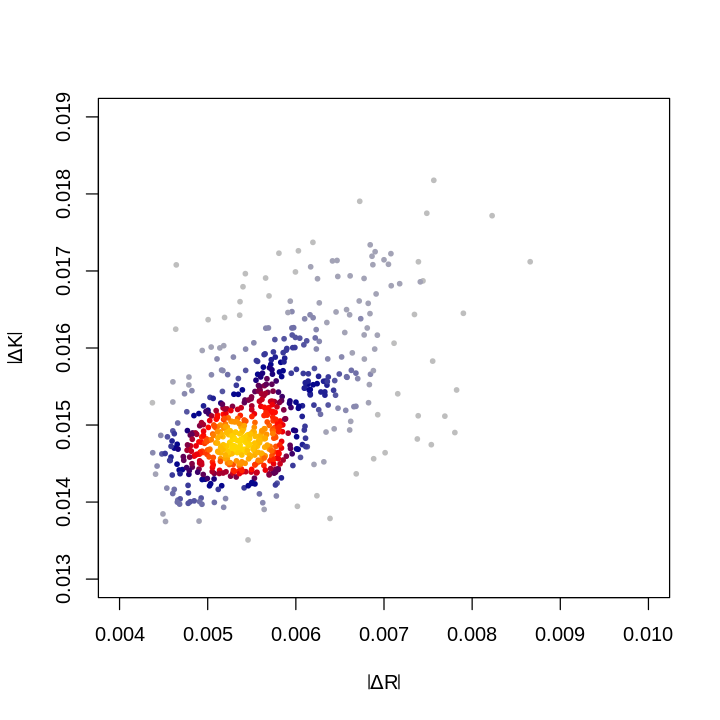

In [87]:
LSD::heatscatter(abs(aa.comp.abundantLeaf-aa.comp.others)[,"R"],abs(aa.comp.abundantLeaf-aa.comp.others)[,"K"],
                 xlab = expression(abs(paste(Delta,"R"))),ylab = expression(abs(paste(Delta,"K"))),main = "",
                 xlim = c(0.004,0.01), ylim = c(0.013,0.019))

In [88]:
cor((aa.comp.abundantLeaf-aa.comp.others)[,"R"],(aa.comp.abundantLeaf-aa.comp.others)[,"K"],method = "spearman")

[1] -0.499868

[1] 0.9499797

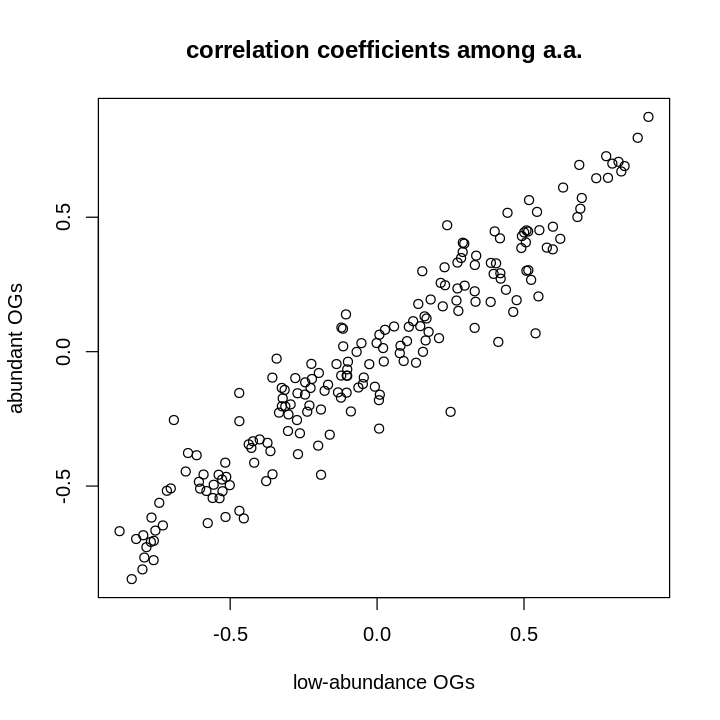

In [89]:
options(repr.plot.width=6, repr.plot.height=6)
plot(as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp.others))]),
     as.vector(cor(aa.comp.abundant)[upper.tri(cor(aa.comp))]),
     xlab = "low-abundance OGs",ylab = "abundant OGs",main = "correlation coefficients among a.a.")
cor(as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),
    as.vector(cor(aa.comp.abundant)[upper.tri(cor(aa.comp))]),method = "spearman")

[1] 0.9043525

[1] 0.6730517

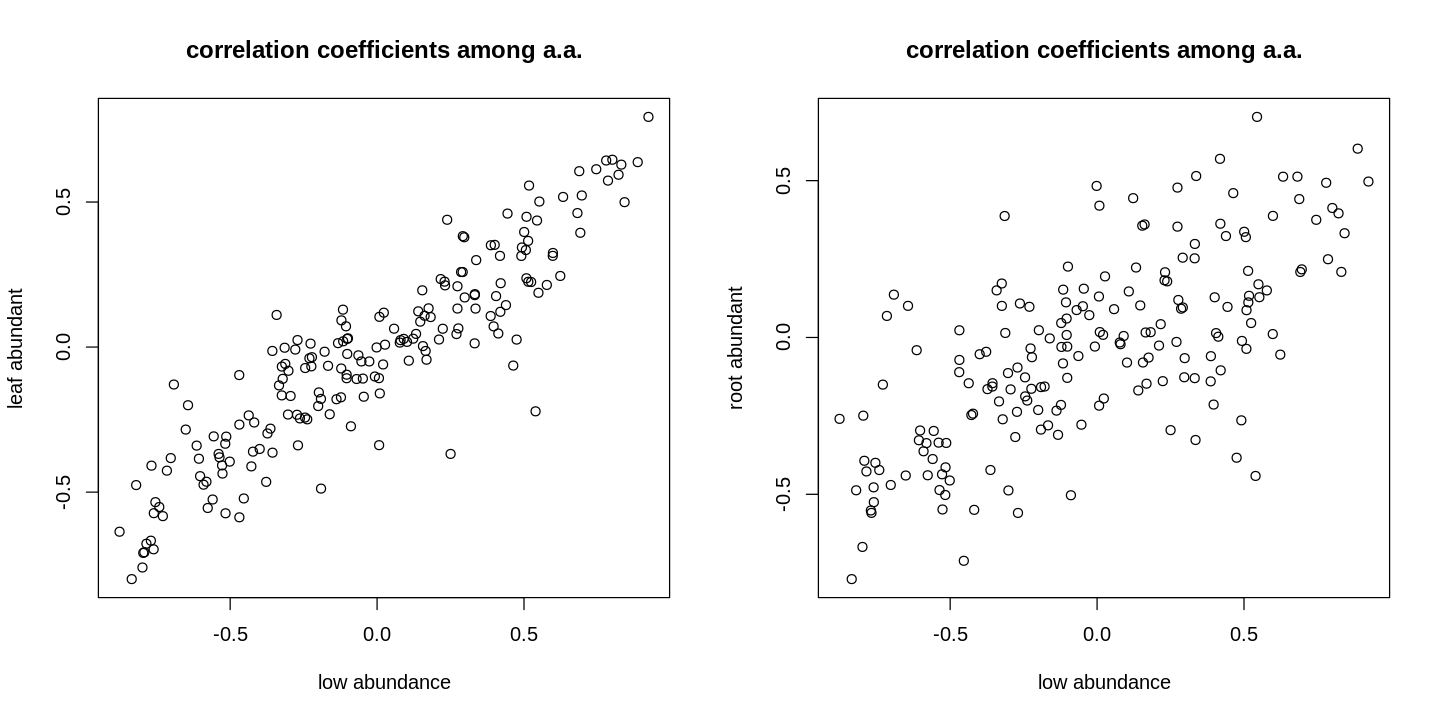

In [90]:
options(repr.plot.width=12, repr.plot.height=6)
par(mfrow = c(1,2))
plot(as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.abundantLeaf)[upper.tri(cor(aa.comp))]),
     xlab = "low abundance",ylab = "leaf abundant",main = "correlation coefficients among a.a.")
cor(as.vector(cor(aa.comp.abundantLeaf)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),method = "spearman")
plot(as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.abundantRoot)[upper.tri(cor(aa.comp))]),
     xlab = "low abundance",ylab = "root abundant",main = "correlation coefficients among a.a.")
cor(as.vector(cor(aa.comp.abundantRoot)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),method = "spearman")


[1] 0.1429236

[1] 0.2641517

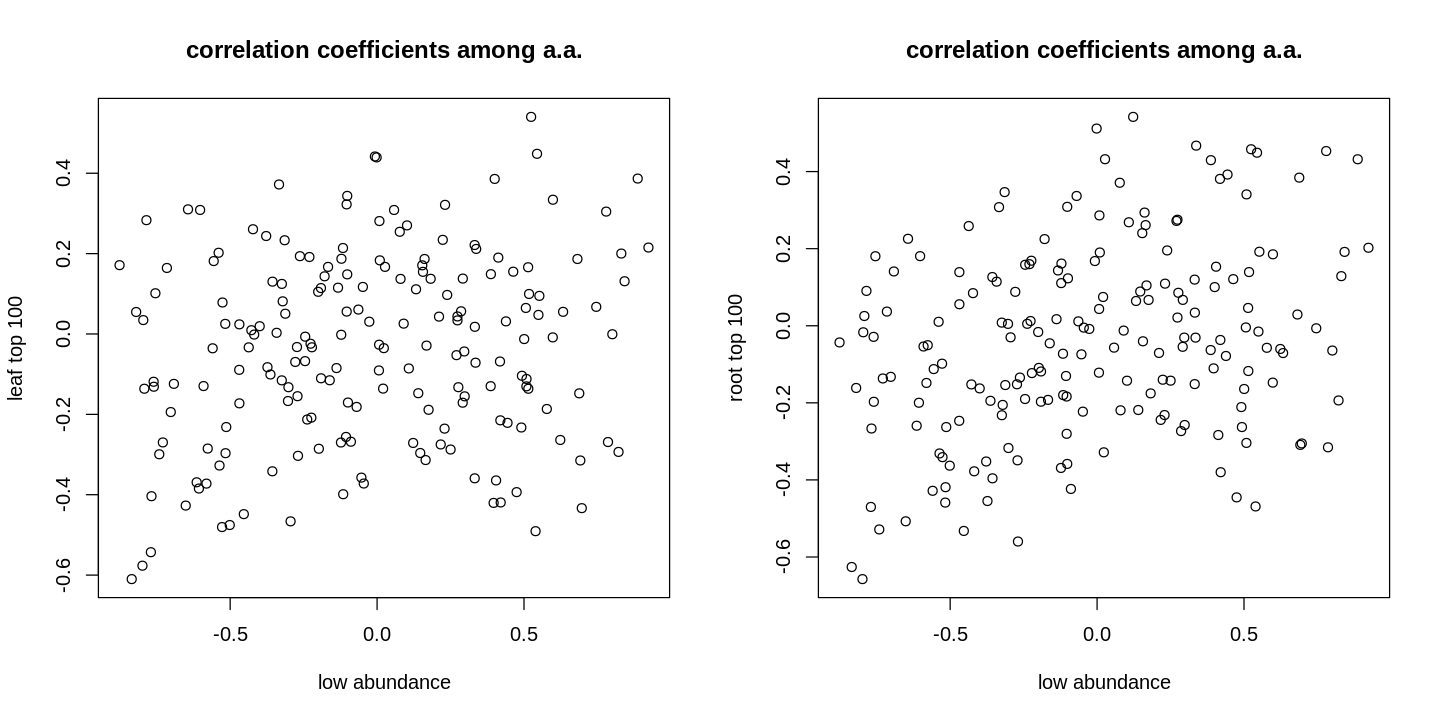

In [91]:
options(repr.plot.width=12, repr.plot.height=6)
par(mfrow = c(1,2))
plot(as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.topLeaf)[upper.tri(cor(aa.comp))]),
     xlab = "low abundance",ylab = "leaf top 100",main = "correlation coefficients among a.a.")
cor(as.vector(cor(aa.comp.topLeaf)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),method = "spearman")
plot(as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.topRoot)[upper.tri(cor(aa.comp))]),
     xlab = "low abundance",ylab = "root top 100",main = "correlation coefficients among a.a.")
cor(as.vector(cor(aa.comp.topRoot)[upper.tri(cor(aa.comp))]),as.vector(cor(aa.comp.others)[upper.tri(cor(aa.comp))]),method = "spearman")



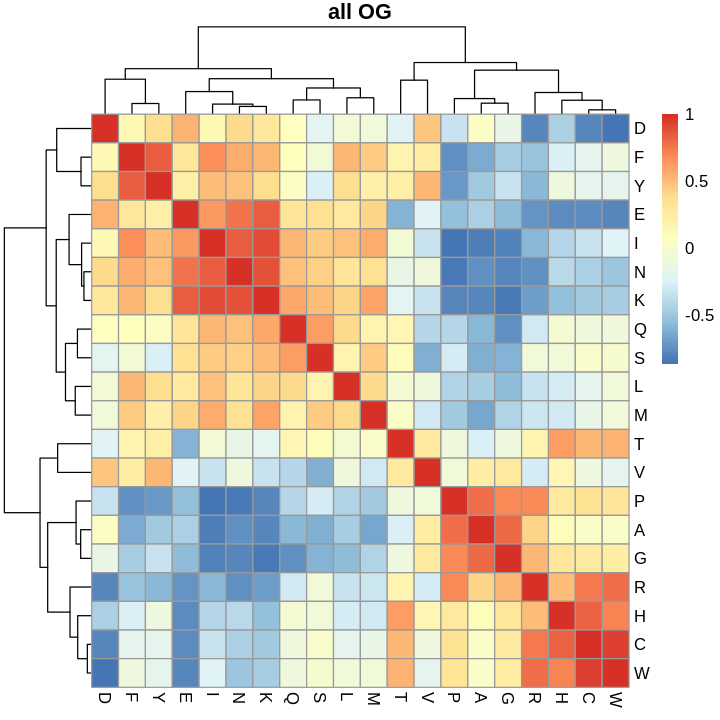

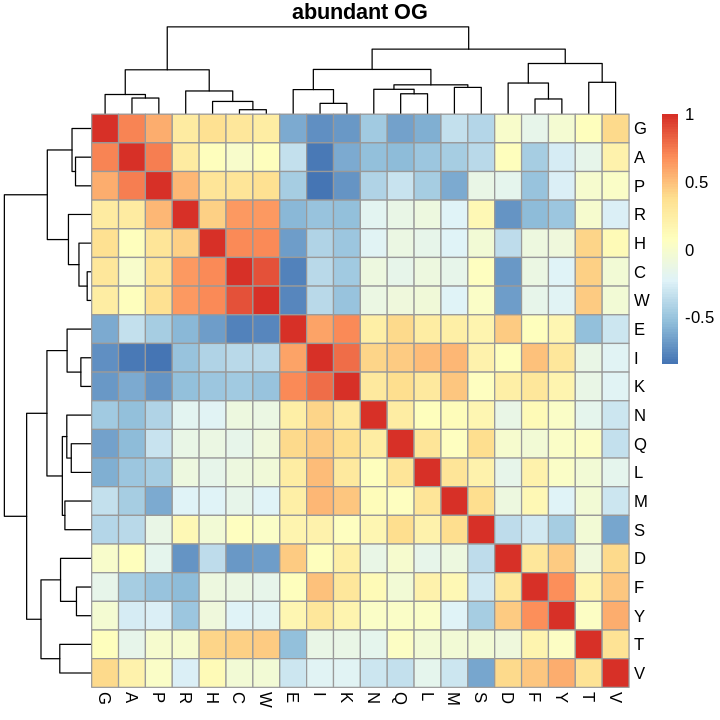

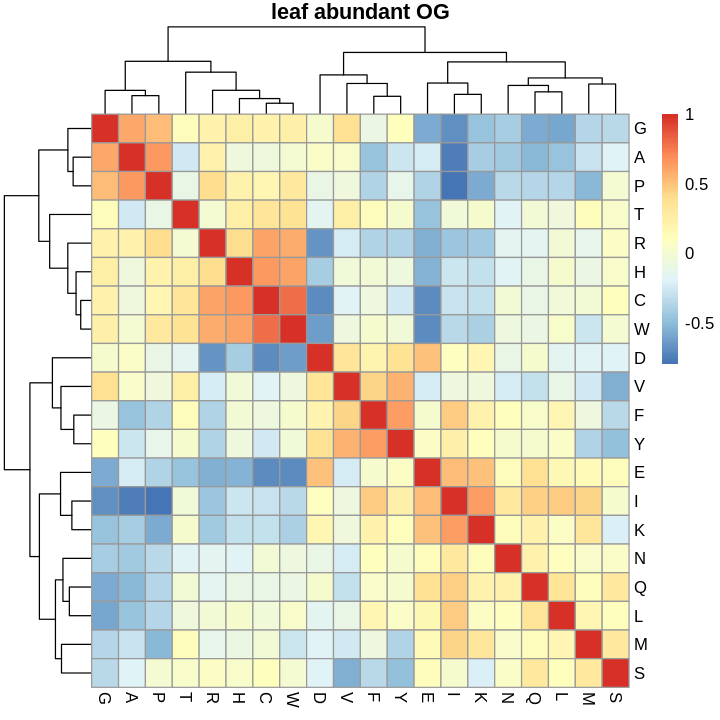

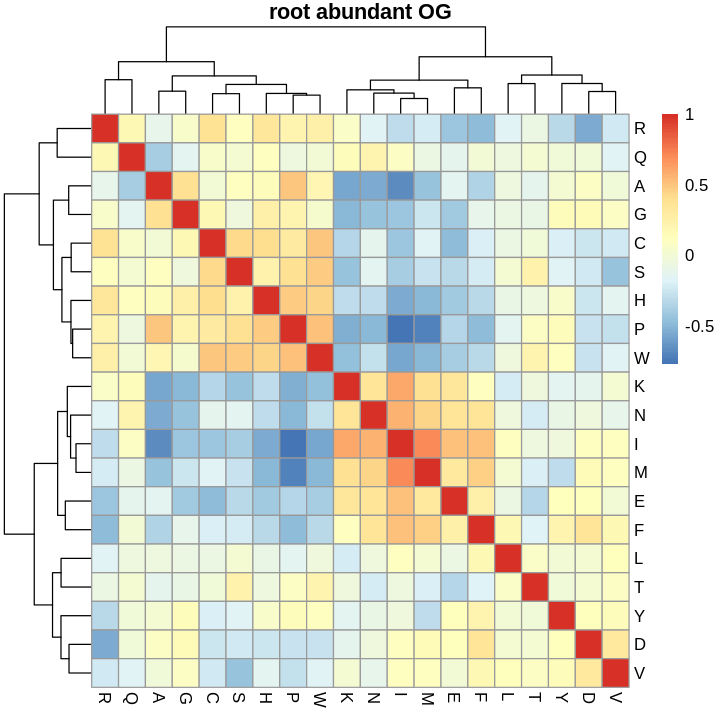

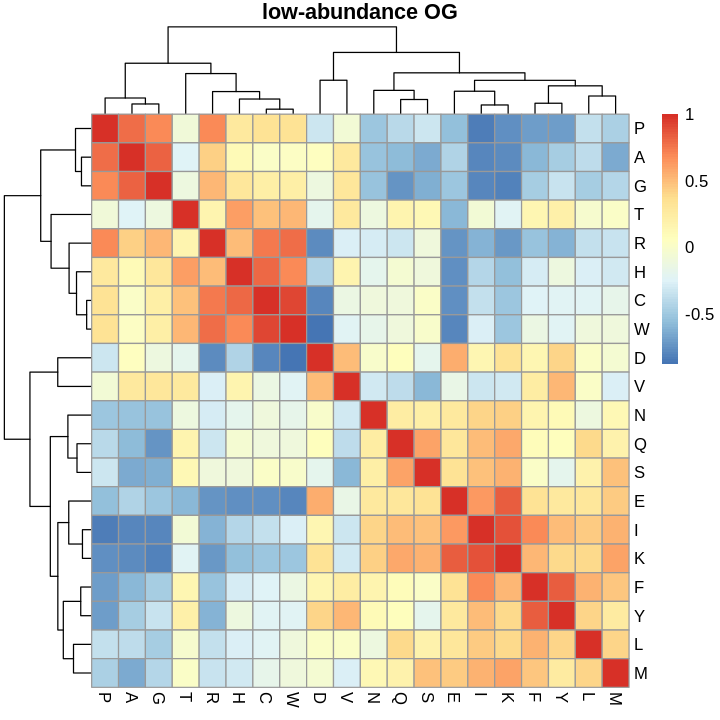

In [92]:
options(repr.plot.width=6, repr.plot.height=6)
pheatmap(cor(aa.comp),main = "all OG")
pheatmap(cor(aa.comp.abundant),main = "abundant OG")
pheatmap(cor(aa.comp.abundantLeaf),main = "leaf abundant OG")
pheatmap(cor(aa.comp.abundantRoot),main = "root abundant OG")
pheatmap(cor(aa.comp.others),main = "low-abundance OG")

# aa to proteome physiochemical properties

In [103]:
aa3 <- c(A="Ala", R="Arg", N="Asn", D="Asp", C="Cys",
         Q="Gln", E="Glu", G="Gly", H="His", I="Ile",
         L="Leu", K="Lys", M="Met", F="Phe", P="Pro",
         S="Ser", T="Thr", W="Trp", Y="Tyr", V="Val",
         B="Asx", Z="Glx", J="Xle", X="Xaa", U="Sec", O="Pyl", "*"="Stop")

one_to_three <- function(x) {
    res <- unname(aa3[toupper(x)])
    return(res)
}

aa.comp1 = aa.comp
aa.comp1.abundant = aa.comp.abundant
aa.comp1.abundantLeaf = aa.comp.abundantLeaf
aa.comp1.abundantRoot = aa.comp.abundantRoot
aa.comp1.others = aa.comp.others

colnames(aa.comp1) = one_to_three(colnames(aa.comp))
colnames(aa.comp1.abundant) = one_to_three(colnames(aa.comp.abundant))
colnames(aa.comp1.abundantLeaf) = one_to_three(colnames(aa.comp.abundantLeaf))
colnames(aa.comp1.abundantRoot) = one_to_three(colnames(aa.comp.abundantRoot))
colnames(aa.comp1.others) = one_to_three(colnames(aa.comp.others))

In [104]:
aa.feat = canprot::calc_metrics(aa.comp1,metrics = c("GRAVY","MW","Density","NC","Cost"))
aa.feat.abundant = canprot::calc_metrics(aa.comp1.abundant,metrics = c("GRAVY","MW","Density","NC","Cost"))
aa.feat.abundantLeaf = canprot::calc_metrics(aa.comp1.abundantLeaf,metrics = c("GRAVY","MW","Density","NC","Cost"))
aa.feat.abundantRoot = canprot::calc_metrics(aa.comp1.abundantRoot,metrics = c("GRAVY","MW","Density","NC","Cost"))
aa.feat.low = canprot::calc_metrics(aa.comp1.others,metrics = c("GRAVY","MW","Density","NC","Cost"))

# GC content calculation (CDS only)

In [135]:
dnaFasta = mclapply(list.files(file.path(PHYLOGWAS_ROOT, "output/CDSperTaxa/"),pattern = "*.fa",full.names = T),function(x) readAAStringSet(x),mc.cores = 30)

dna.comp = mclapply(dnaFasta,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    return(colSums(tmp)/sum(tmp))
},mc.cores = 30)


dna.comp = Reduce("rbind",dna.comp)

rownames(dna.comp) = gsub(".fa","",list.files(file.path(PHYLOGWAS_ROOT, "output/CDSperTaxa/"),pattern = "*.fa"))

dna.comp = dna.comp[commonID,]

dim(dna.comp)

[1] 687   4

In [136]:
fwrite(dna.comp,file.path(PHYLOGWAS_ROOT, "output/poaceae_dnaComposition_20251008.txt"),sep = "\t",row.names = T,col.names = T)

x being coerced from class: matrix to data.table



In [107]:
dna.comp = read.table(file.path(PHYLOGWAS_ROOT, "output/poaceae_dnaComposition_20251008.txt"),row.names =1,header = T)

In [108]:
cgCont = rowSums(dna.comp[,3:4])

### per OG

In [109]:
dnaFastaPerOG = mclapply(list.files(file.path(PHYLOGWAS_ROOT, "output/CDSMSAPerOG/"),pattern = "*.fa",full.names = T),
                         function(x) readDNAStringSet(x),mc.cores = 5)

names(dnaFastaPerOG) = gsub("_mafft.fa","",list.files(file.path(PHYLOGWAS_ROOT, "output/CDSMSAPerOG/"),pattern = "*.fa"))
dna.comp.perOG = mclapply(dnaFastaPerOG,function(x){
    tmp = letterFrequency(x,letters = c("A","T","C","G"))
    rownames(tmp) = names(x)
    tmp = apply(tmp,2,function(a) tapply(a,limma::strsplit2(rownames(tmp),":")[,2],sum))
    return(as.data.frame(tmp)[commonID,])
},mc.cores = 5)


dna.comp.perOG.array = simplify2array(lapply(dna.comp.perOG,as.matrix))

In [110]:
dna.prop.perOG = array(apply(dna.comp.perOG.array,3,function(x) x/rowSums(x,na.rm = T)),dim = dim(dna.comp.perOG.array))
dimnames(dna.prop.perOG) = dimnames(dna.comp.perOG.array)

In [111]:
cgCont.new = apply(dna.comp.perOG.array,c(1,2),sum,na.rm = T)
cgCont.new = rowSums(cgCont.new[,3:4]/rowSums(cgCont.new))


In [112]:
cgCont.abundant = apply(dna.comp.perOG.array[,,intersect(abundantOG,dimnames(dna.prop.perOG)[[3]])],c(1,2),sum,na.rm = T)
cgCont.abundant = rowSums(cgCont.abundant[,3:4]/rowSums(cgCont.abundant))
cgCont.abundantLeaf = apply(dna.comp.perOG.array[,,intersect(abundantOGLeaf,dimnames(dna.prop.perOG)[[3]])],c(1,2),sum,na.rm = T)
cgCont.abundantLeaf = rowSums(cgCont.abundantLeaf[,3:4]/rowSums(cgCont.abundantLeaf))
cgCont.abundantRoot = apply(dna.comp.perOG.array[,,intersect(abundantOGRoot,dimnames(dna.prop.perOG)[[3]])],c(1,2),sum,na.rm = T)
cgCont.abundantRoot = rowSums(cgCont.abundantRoot[,3:4]/rowSums(cgCont.abundantRoot))
cgCont.topLeaf = apply(dna.comp.perOG.array[,,intersect(topOGLeaf,dimnames(dna.prop.perOG)[[3]])],c(1,2),sum,na.rm = T)
cgCont.topLeaf = rowSums(cgCont.topLeaf[,3:4]/rowSums(cgCont.topLeaf))
cgCont.topRoot = apply(dna.comp.perOG.array[,,intersect(topOGRoot,dimnames(dna.prop.perOG)[[3]])],c(1,2),sum,na.rm = T)
cgCont.topRoot = rowSums(cgCont.topRoot[,3:4]/rowSums(cgCont.topRoot))


In [113]:
cgCont.low = apply(dna.comp.perOG.array[,,setdiff(dimnames(dna.prop.perOG)[[3]],abundantOG)],c(1,2),sum,na.rm = T)
cgCont.low = rowSums(cgCont.low[,3:4]/rowSums(cgCont.low))


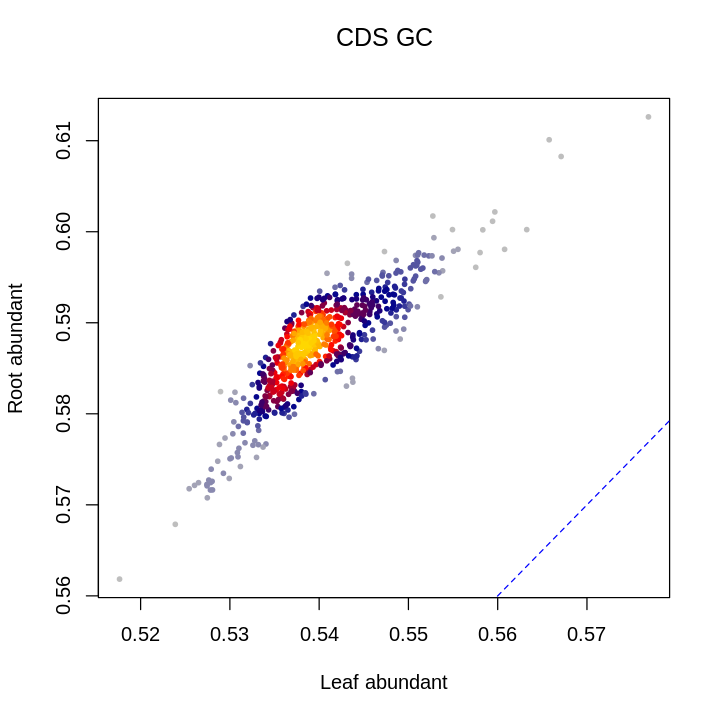

In [114]:
LSD::heatscatter(cgCont.abundantLeaf,cgCont.abundantRoot,main = "CDS GC",
                 xlab = "Leaf abundant",ylab = "Root abundant")
abline(a = 0, b =1, col = "blue",lty = 2)

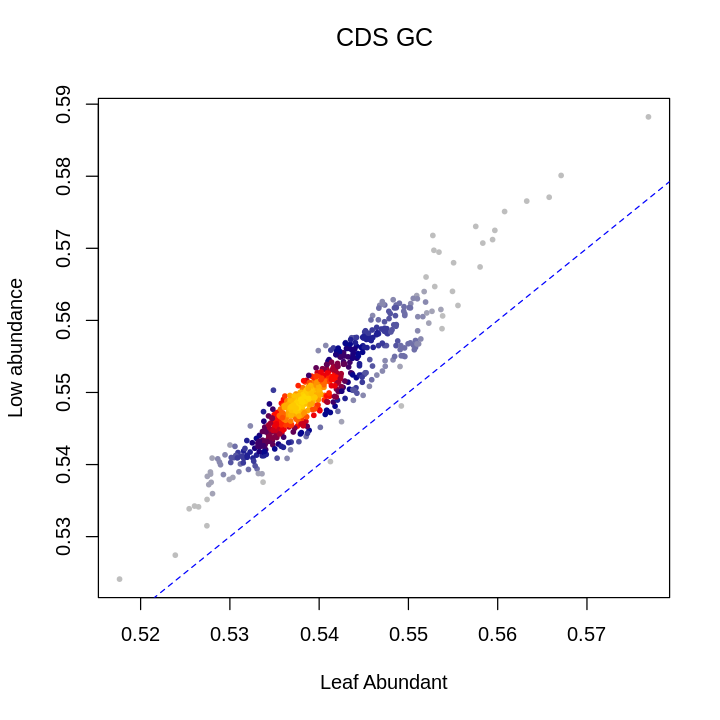

In [115]:
LSD::heatscatter(cgCont.abundantLeaf,cgCont.low,main = "CDS GC",
                 xlab = "Leaf Abundant",ylab = "Low abundance")
abline(a = 0, b =1, col = "blue",lty = 2)

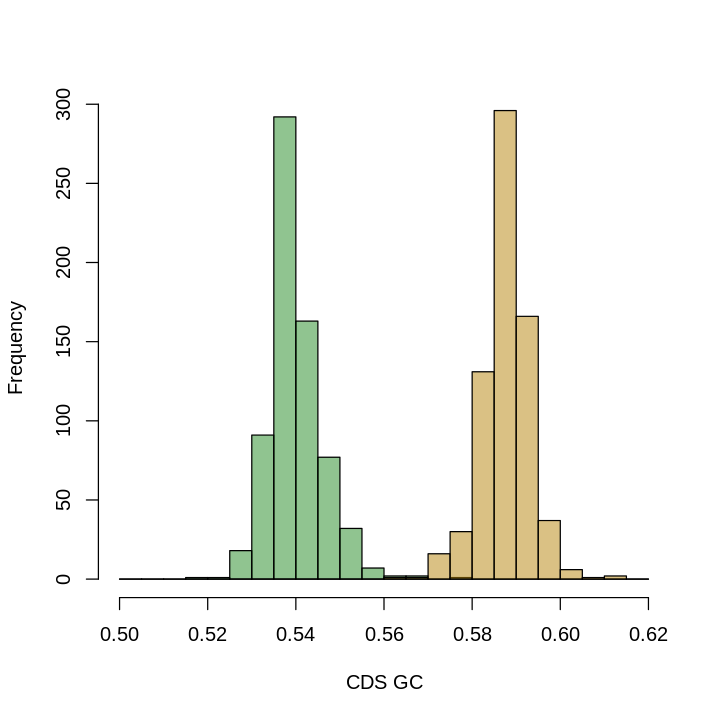

In [116]:
hist(cgCont.abundantLeaf,breaks = seq(0.5,.62,.005),col = alpha("forestgreen",.5),main = "",xlab = "CDS GC")
hist(cgCont.abundantRoot,breaks = seq(0.5,.62,.005),col = alpha("darkgoldenrod",.5),add =T)

In [10]:
myX = cbind(aa.feat,"GC" = cgCont[commonID])
myX2 = cbind(aa.feat.abundant,"GC" = cgCont.abundant[commonID])
myX3 = cbind(aa.feat.abundantLeaf,"GC" = cgCont.abundantLeaf[commonID])
myX4 = cbind(aa.feat.abundantRoot,"GC" = cgCont.abundantRoot[commonID])
myX5 = cbind(aa.feat.low,"GC" = cgCont.low[commonID])

ERROR: Error in eval(quote(list(...)), env): object 'aa.feat' not found


In [124]:
fwrite(myX,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_20251008.txt"),quote = F, row.name =T,sep = "\t")
fwrite(myX2,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_abundant_20251008.txt"),quote = F, row.name =T,sep = "\t")
fwrite(myX3,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_abundantLeaf_20251008.txt"),quote = F, row.name =T,sep = "\t")
fwrite(myX4,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_abundantRoot_20251008.txt"),quote = F, row.name =T,sep = "\t")
fwrite(myX5,file.path(PHYLOGWAS_ROOT, "output/genomicFeatureData_low_20251008.txt"),quote = F, row.name =T,sep = "\t")